### EDA EXPERIMENTATION

- Data used : *`titanic`* of ***Seaborn***
- _ 
___

#### 1rst STEP : IMPORTATION DES BIBLIOTHÈQUES
```sh
pip install <packages_name>
```

In [1]:
# import machine_learning as ml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
%matplotlib inline

#### 2nd STEP : IMPORTATION DES DONNÉES

In [2]:
titanic_df = sns.load_dataset('titanic')

In [3]:
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


---

#### 3rd STEP : INFORMATIONS SUR LES DONNÉES DU DATASET

In [4]:
# print(f"Dataset shape: {titanic_df.shape} (rows, columns)")

```py
"""
>>> INFORMATIONS STATISTIQUES ET DÉTAILLÉES DES DONNÉES DU DATASETS [les ÉTIQUETTES]
"""
```

In [5]:
titanic_df.info()   # detailed informations on dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


```py
"""
>>> STATISTIQUE DESCRIPTIVE SUR LES DONNÉES NUMÉRIQUES
"""
```

In [6]:
titanic_df.describe().round(2)   # data descrirtions

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


___

#### 4th STEP : DÉTECTION DES VALEURS POUVANT AFFECTER LA QUALITÉ DE L'ANALYSE ET PAR SUITE DU MODÈLE

##### Catégorie A : Valeurs Manquantes
```
>>>
```

In [7]:
print(f"Missing values:\n{'='*72}")
titanic_df.isna().head()

Missing values:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [8]:
print(f"\t Missing values count:\n{'='*72}\n{titanic_df.isna().sum()}")

	 Missing values count:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


##### Catégorie B : Valeurs Dupliquées
```
>>>
```

In [9]:
print(titanic_df.duplicated())
f"Count Of duplicated values: {int(f"{titanic_df.duplicated().sum()}")}"

0      False
1      False
2      False
3      False
4      False
       ...  
886     True
887    False
888    False
889    False
890    False
Length: 891, dtype: bool


'Count Of duplicated values: 107'

In [10]:
titanic_df[titanic_df.duplicated()].sort_values(by=list(titanic_df.columns))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
295,0,1,male,NaN,0,0,27.7208,C,First,man,True,NaN,Cherbourg,no,True
757,0,2,male,18.0,0,0,11.5000,S,Second,man,True,NaN,Southampton,no,True
733,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
734,0,2,male,23.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
343,0,2,male,25.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,1,3,female,NaN,1,0,15.5000,Q,Third,woman,False,NaN,Queenstown,yes,False
431,1,3,female,NaN,1,0,16.1000,S,Third,woman,False,NaN,Southampton,yes,False
838,1,3,male,32.0,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
692,1,3,male,NaN,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True


##### Catégorie C : Valeurs Aberrantes
```py
"""
>>> IQR methods
"""
```

___

### >>> Missing_[4-cols] & Duplicated_[107] values

**Missing** *
- age :            177
- embarked :         2
- deck :           688
- embark_town :      2

In [11]:
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

<Axes: >

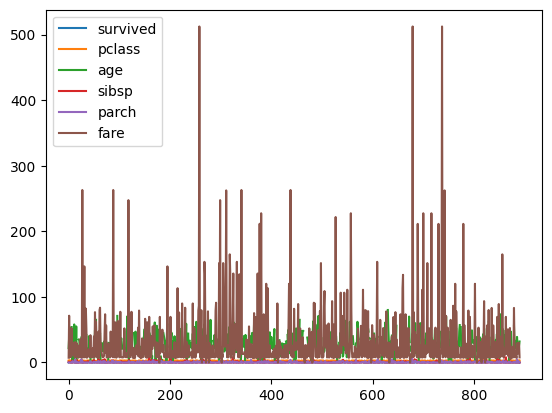

In [15]:
titanic_df.plot()

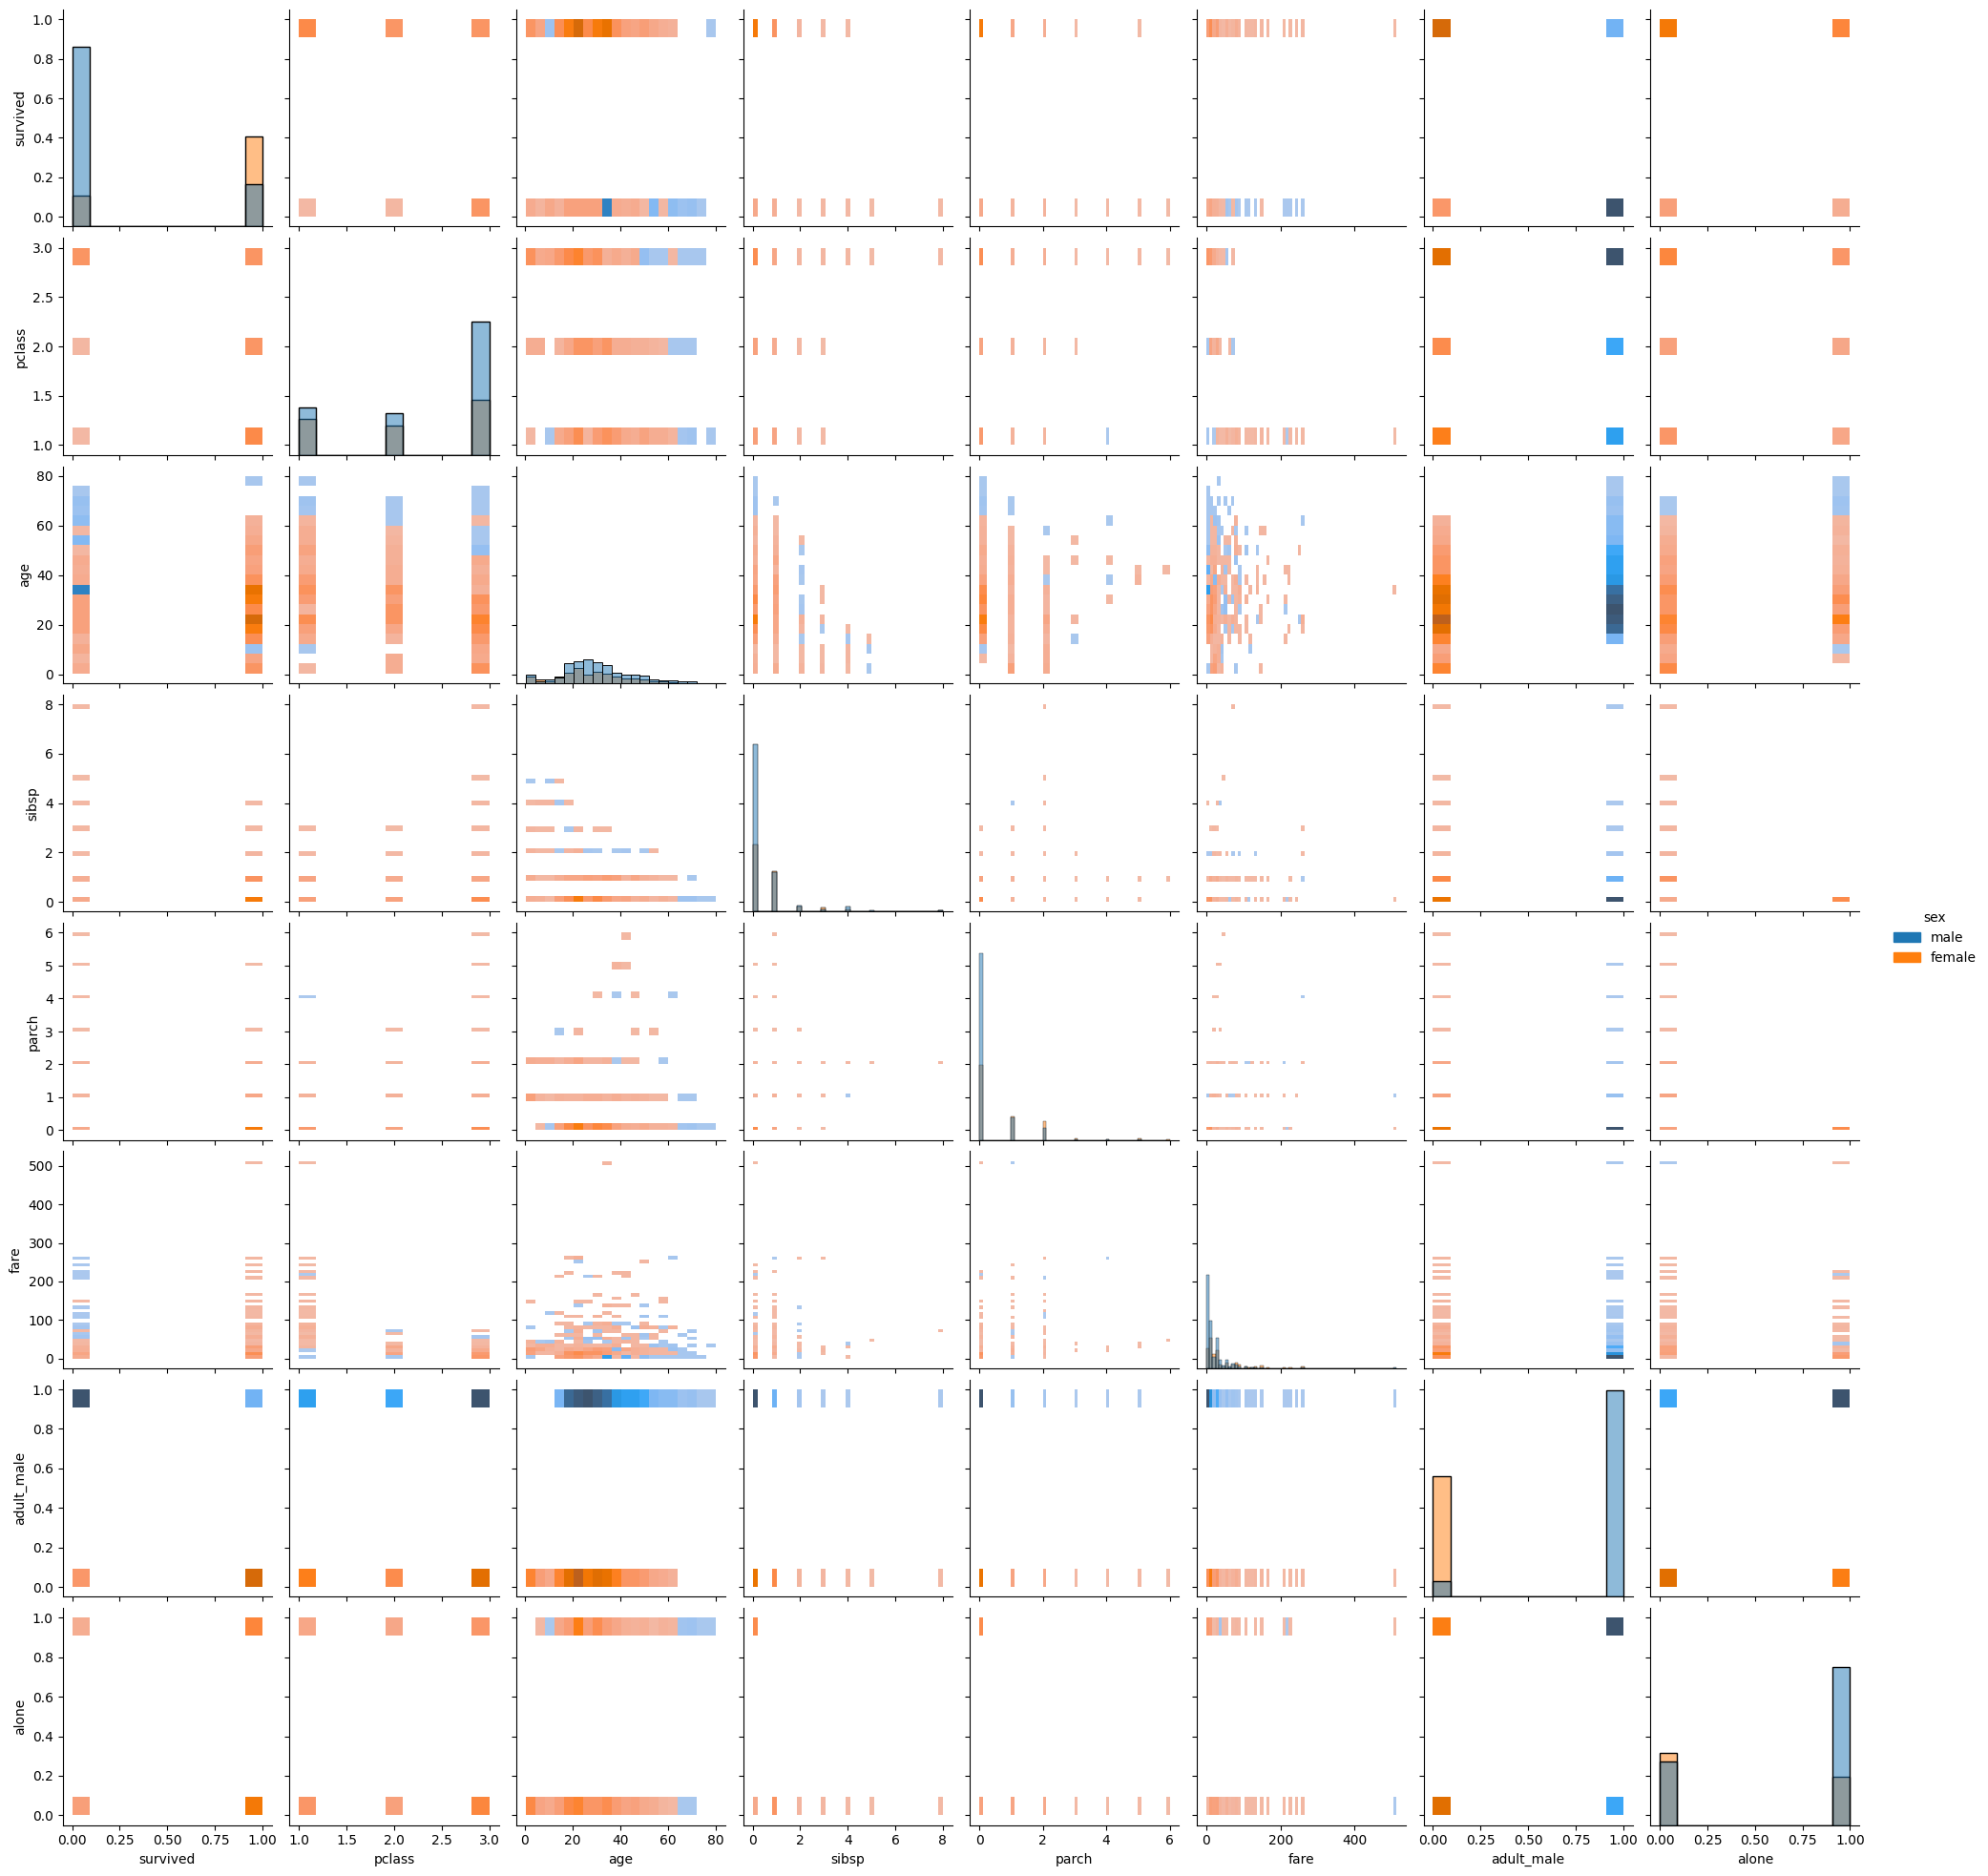

In [17]:
sns.pairplot(titanic_df, hue="sex", kind="hist")

---

In [18]:
encoder = LabelEncoder()

In [ ]:
# Encoding Values
tt_df = encoder.fit_transform()
tt_df

In [ ]:
X = titanic_df.drop("", axis=1)
X

In [ ]:
y = titanic_df[""]
y

In [ ]:
# Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

---

---

___